                       name country region  latitude  longitude  elevation  \
id                                                                           
D1424    Frankfurt  Westend      DE     HE   50.1269     8.6694        124   
10640     Offenbach am Main      DE     HE   50.1167     8.7333         98   
10641  Offenbach Wetterpark      DE     HE   50.0894     8.7864        119   
10637     Frankfurt Airport      DE     HE   50.0500     8.6000        111   

            timezone  distance  
id                              
D1424  Europe/Berlin    1649.3  
10640  Europe/Berlin    3503.5  
10641  Europe/Berlin    7845.6  
10637  Europe/Berlin    9441.4  


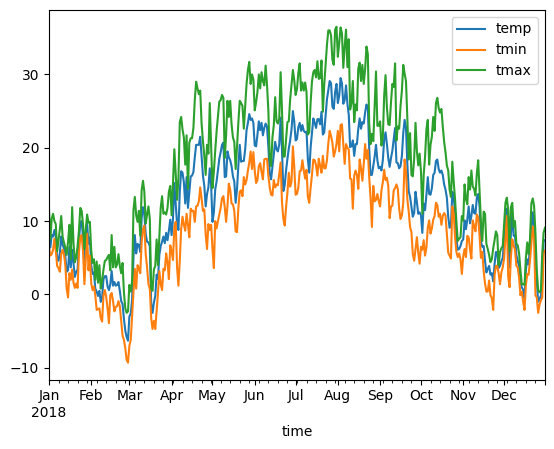

In [49]:
from datetime import date
import matplotlib.pyplot as plt
import meteostat as ms

# Specify location and time range
POINT = ms.Point(50.1155, 8.6842, 113)  # Try with your location
START = date(2018, 1, 1)
END = date(2018, 12, 31)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)
print(stations)
# Get daily data & perform interpolation
ts = ms.daily(stations, START, END)
df = ms.interpolate(ts, POINT).fetch()

# Plot line chart including average, minimum and maximum temperature
df.plot(y=[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX])
plt.show()


In [50]:
import pandas as pd
# Importing Nodes and Edges of Network
nodes = pd.read_csv(f"Florida_nodeList.csv")
edges = pd.read_csv(f"Florida_edgeList.csv")



for node in nodes.index:
    point = ms.Point(nodes.loc[node, "latitude"], nodes.loc[node, "longitude"], nodes.loc[node, "elevation"])
    print(nodes.loc[node, "latitude"], nodes.loc[node, "longitude"], nodes.loc[node, "elevation"])
    print(ms.stations.nearby(point, limit=1))
    break

# # Loop through weather events
# rainNodes = np.zeros((num_hours, len(nodes.index)))
# windNodes = np.zeros((num_hours, len(nodes.index)))
# tempNodes = np.zeros((num_hours, len(nodes.index)))
# humidityNodes = np.zeros((num_hours, len(nodes.index)))


30.2902 -87.5099 2.333333
                                             name country region  latitude  \
id                                                                           
KJKA0  Gulf Shores / Bay Village Mobile Home Park      US     AL   30.2896   

       longitude  elevation         timezone  distance  
id                                                      
KJKA0   -87.6718          5  America/Chicago   15545.0  


In [51]:
import meteostat as ms
import pandas as pd

# Approximate Florida bounding box
lat_vals = [15, 20, 25, 30, 35, 40, 45]
lon_vals = [-90, -80, -70, -60, -50, -40]

all_stations = []

for lat in lat_vals:
    for lon in lon_vals:
        point = ms.Point(lat, lon)
        try:
            df = ms.stations.nearby(point, radius=2000000, limit=5000)
            if df is not None and not df.empty:
                df = df.reset_index()   # station id becomes a column
                all_stations.append(df)
        except Exception as e:
            print(f"Skipped point ({lat}, {lon}): {e}")

if all_stations:
    florida_stations = pd.concat(all_stations, ignore_index=True)

    # Keep only stations inside Florida-ish bounds
    florida_stations = florida_stations[
        (florida_stations["latitude"] >= 24.0) &
        (florida_stations["latitude"] <= 31.5) &
        (florida_stations["longitude"] >= -87.7) &
        (florida_stations["longitude"] <= -79.8)
    ]

    # Deduplicate station ids
    florida_stations = florida_stations.drop_duplicates(subset="id").sort_values("id")
    print(florida_stations)
    # print(f"Found {len(florida_stations)} stations")
    # print(florida_stations[["id", "name", "country", "region", "latitude", "longitude", "distance"]])

    florida_stations.to_csv("florida_stations.csv", index=False)
else:
    print("No stations found.")


        id                             name country region  latitude  \
431  52GQ6         Palatka Kay Larkin Field      US     FL  29.65860   
343  69052                      Mary Esther      US     FL  30.42000   
157  72201                 Key West Airport      US     FL  24.55000   
198  72202      Miami International Airport      US     FL  25.78330   
253  72203         Palm Beach International      US     FL  26.68330   
..     ...                              ...     ...    ...       ...   
337  OZNF7  Pensacola International Airport      US     FL  30.47806   
215  QZ5US                Airglades Airport      US     FL  26.73517   
471  TMSWZ       Headland Municipal Airport      US     AL  31.36414   
437  VFP98          Suwannee County Airport      US     FL  30.30010   
325  YZNBG      Sebastian Municipal Airport      US     FL  27.81325   

     longitude  elevation          timezone   distance  
431  -81.68890         15  America/New_York  1838843.8  
343  -86.68000       

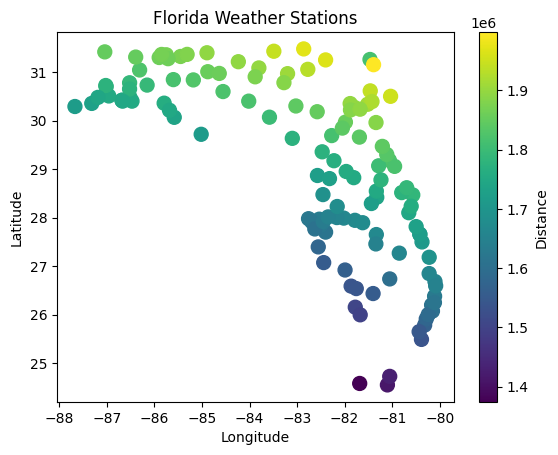

In [52]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(florida_stations["longitude"], florida_stations["latitude"], c=florida_stations["distance"], cmap="viridis", s=100)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Florida Weather Stations")
plt.colorbar(label="Distance")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.neighbors import BallTree

# florida_stations should already exist from your earlier filtering step
# Expected columns: latitude, longitude
df = florida_stations.copy().reset_index(drop=True)

# Keep only rows with valid coordinates
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)

# Optional: create a station id if one does not exist
if "id" not in df.columns:
    df["id"] = df.index.astype(str)

# Build graph
G = nx.Graph()
nodeDict = []
# Add nodes with useful attributes
for _, row in df.iterrows():
    G.add_node(
        row["id"],
        latitude=row["latitude"],
        longitude=row["longitude"],
        name=row["name"] if "name" in df.columns else row["id"]
    )
    nodeDict.append(
        {
        "id":           row["id"],
        'latitude':     row["latitude"],
        'longitude':    row["longitude"],
        "elevation":    row["elevation"] if "elevation" in df.columns else None,        }
    )
# Build edges using k-nearest neighbors based on lat/lon
# k = number of nearby stations each node connects to
k = 3

coords_deg = df[["latitude", "longitude"]].to_numpy()
coords_rad = np.radians(coords_deg)

tree = BallTree(coords_rad, metric="haversine")
distances, indices = tree.query(coords_rad, k=k + 1)  # +1 because first neighbor is itself

EARTH_RADIUS_KM = 6371.0

for i in range(len(df)):
    source_id = df.loc[i, "id"]
    
    for j_idx, dist_rad in zip(indices[i][1:], distances[i][1:]):
        target_id = df.loc[j_idx, "id"]
        distance_km = dist_rad * EARTH_RADIUS_KM
        
        # Avoid duplicate edges in undirected graph
        if not G.has_edge(source_id, target_id):
            G.add_edge(source_id, target_id, weight=distance_km)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
# Convert Edge List and Node List to Panda Dataframes
el = nx.to_pandas_edgelist(G)
nl = pd.DataFrame(nodeDict)

# Convert Panda Dataframes to Edge List and Node List CSV
pd.DataFrame.to_csv(nl,'Florida_meteo_nodeList.csv')
pd.DataFrame.to_csv(el,'Florida_meteo_edgeList.csv')


Graph has 128 nodes and 241 edges


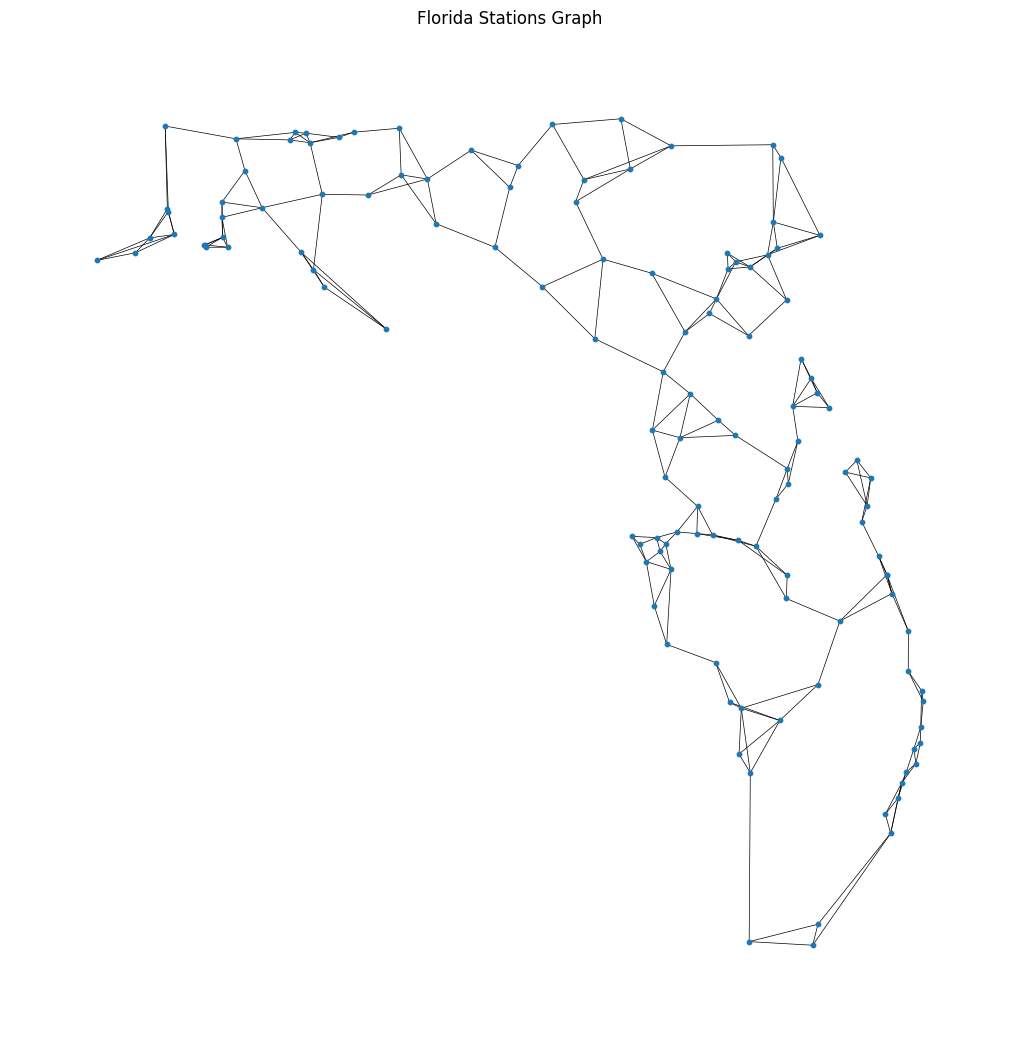

In [43]:
import matplotlib.pyplot as plt

pos = {
    row["id"]: (row["longitude"], row["latitude"])
    for _, row in df.iterrows()
}

plt.figure(figsize=(10, 10))
nx.draw(
    G,
    pos,
    node_size=10,
    width=0.5,
    with_labels=False
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Florida Stations Graph")
plt.show()


In [44]:
ms.config.block_large_requests = False
START = date(2018, 1, 1)
END = date(2018, 12, 31)
ts = ms.hourly(florida_stations["id"], START, END,parameters=[ms.Parameter.TEMP, ms.Parameter.PRCP, ms.Parameter.WSPD, ms.Parameter.RHUM])


In [45]:
df = ts.fetch()
# print(df)
df['temp'] = df['temp']*9/5 + 32  # Convert to Fahrenheit if needed

df['wspd'] = df['wspd']*0.6213711922
print(df)


                              temp  rhum  prcp       wspd
station time                                             
72201   2018-01-01 00:00:00  66.92    63  <NA>   5.840889
        2018-01-01 01:00:00  66.02    70   0.0   3.355404
        2018-01-01 02:00:00  66.02    73   0.0   3.355404
        2018-01-01 03:00:00  66.92    70   0.0   5.840889
        2018-01-01 04:00:00  69.08    66   0.0   4.722421
...                            ...   ...   ...        ...
KZPH0   2018-12-31 18:00:00  81.32    54  <NA>  17.211982
        2018-12-31 20:00:00  82.04    52  <NA>  12.738109
        2018-12-31 21:00:00  81.32    52  <NA>   9.196294
        2018-12-31 22:00:00  80.06    55  <NA>   6.959357
        2018-12-31 23:00:00  76.46    64  <NA>   3.355404

[803079 rows x 4 columns]


In [46]:
import numpy as np

station_coords = florida_stations.copy()
station_coords['latitude'] = pd.to_numeric(station_coords['latitude'], errors='coerce')
station_coords['longitude'] = pd.to_numeric(station_coords['longitude'], errors='coerce')
station_coords = station_coords.dropna(subset=['latitude', 'longitude'])[['id', 'latitude', 'longitude']].drop_duplicates('id')

coord_lookup = station_coords.set_index('id')[['latitude', 'longitude']]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
k = 3

def fill_group_from_nearby(group):
    group = group.copy()
    station_ids = group.index.get_level_values('station') if 'station' in group.index.names else group.index

    latitudes = station_ids.map(coord_lookup['latitude'])
    longitudes = station_ids.map(coord_lookup['longitude'])

    for col in numeric_cols:
        values = pd.to_numeric(group[col], errors='coerce').to_numpy(dtype=float)
        coords = np.column_stack([latitudes.to_numpy(dtype=float), longitudes.to_numpy(dtype=float)])

        missing_idx = np.where(np.isnan(values))[0]
        known_idx = np.where(~np.isnan(values) & ~np.isnan(coords[:, 0]) & ~np.isnan(coords[:, 1]))[0]

        if len(known_idx) == 0:
            continue

        for i in missing_idx:
            if np.isnan(coords[i, 0]) or np.isnan(coords[i, 1]):
                continue

            dists = np.sqrt(
                (coords[known_idx, 0] - coords[i, 0]) ** 2 +
                (coords[known_idx, 1] - coords[i, 1]) ** 2
            )

            nearest = known_idx[np.argsort(dists)[:k]]
            if len(nearest) > 0:
                values[i] = np.nanmean(values[nearest])

        group[col] = values

    return group

if isinstance(df.index, pd.MultiIndex) and 'time' in df.index.names:
    df = df.groupby(level='time', group_keys=False).apply(fill_group_from_nearby)
else:
    df = fill_group_from_nearby(df)

# Second pass for precipitation: fill any leftovers within each station over time.
if isinstance(df.index, pd.MultiIndex) and {'station', 'time'}.issubset(df.index.names) and 'prcp' in df.columns:
    df = df.sort_index()
    df['prcp'] = (
        df['prcp']
        .groupby(level='station', group_keys=True)
        .apply(lambda s: pd.to_numeric(s.droplevel('station'), errors='coerce').sort_index().interpolate(method='time').ffill().bfill())
    )

print(df.isna().sum())
print('Remaining precipitation NaNs:', int(df['prcp'].isna().sum()) if 'prcp' in df.columns else 'prcp not found')
df.head()


temp    0
rhum    0
prcp    0
wspd    0
dtype: int64
Remaining precipitation NaNs: 0


temp  rhum  prcp      wspd
station time                                            
72201   2018-01-01 00:00:00  66.92  63.0   0.0  5.840889
        2018-01-01 01:00:00  66.02  70.0   0.0  3.355404
        2018-01-01 02:00:00  66.02  73.0   0.0  3.355404
        2018-01-01 03:00:00  66.92  70.0   0.0  5.840889
        2018-01-01 04:00:00  69.08  66.0   0.0  4.722421

In [48]:
from pathlib import Path
import numpy as np

feature_cols = ['temp', 'rhum', 'prcp', 'wspd']
feature_file_names = {
    'temp': 'temp_data.csv',
    'rhum': 'humidity_data.csv',
    'prcp': 'rain_data.csv',
    'wspd': 'wind_speed_data.csv'
}
output_root = Path('WeatherData')

if not isinstance(df.index, pd.MultiIndex) or not {'station', 'time'}.issubset(df.index.names):
    raise ValueError("df must have a MultiIndex with 'station' and 'time' levels.")

all_station_ids = pd.Index(florida_stations['id'].astype(str).drop_duplicates(), name='station')
station_lookup = florida_stations.copy()
station_lookup['id'] = station_lookup['id'].astype(str)
station_lookup['latitude'] = pd.to_numeric(station_lookup['latitude'], errors='coerce')
station_lookup['longitude'] = pd.to_numeric(station_lookup['longitude'], errors='coerce')
station_lookup = station_lookup.dropna(subset=['latitude', 'longitude']).drop_duplicates('id')
station_lookup = station_lookup.set_index('id').reindex(all_station_ids)
station_coords = station_lookup[['latitude', 'longitude']].to_numpy(dtype=float)

def fill_daily_matrix(daily_matrix, k=3):
    filled = daily_matrix.copy()

    for col in filled.columns:
        values = np.array(pd.to_numeric(filled[col], errors='coerce'), dtype=float, copy=True)
        missing_idx = np.where(np.isnan(values))[0]
        known_idx = np.where(~np.isnan(values) & ~np.isnan(station_coords[:, 0]) & ~np.isnan(station_coords[:, 1]))[0]

        if len(known_idx) == 0:
            continue

        for i in missing_idx:
            if np.isnan(station_coords[i, 0]) or np.isnan(station_coords[i, 1]):
                continue

            dists = np.sqrt(
                (station_coords[known_idx, 0] - station_coords[i, 0]) ** 2 +
                (station_coords[known_idx, 1] - station_coords[i, 1]) ** 2
            )

            nearest = known_idx[np.argsort(dists)[:k]]
            if len(nearest) > 0:
                values[i] = np.nanmean(values[nearest])

        filled[col] = values

    filled = filled.apply(
        lambda row: pd.Series(row, index=filled.columns).interpolate(limit_direction='both'),
        axis=1
    )
    return filled

daily_feature_datasets = {}

for feature in feature_cols:
    if feature not in df.columns:
        continue

    feature_df = df[[feature]].reset_index().copy()
    feature_df['station'] = feature_df['station'].astype(str)
    feature_df['date'] = feature_df['time'].dt.date
    feature_df['hour'] = feature_df['time'].dt.hour

    daily_feature_datasets[feature] = {}

    for date_value, group in feature_df.groupby('date'):
        daily_matrix = (
            group.pivot_table(
                index='station',
                columns='hour',
                values=feature,
                aggfunc='first'
            )
            .reindex(columns=range(24))
            .reindex(all_station_ids)
            .sort_index()
        )
        daily_matrix.columns = [f'hour_{hour:02d}' for hour in daily_matrix.columns]
        daily_matrix = fill_daily_matrix(daily_matrix)
        daily_feature_datasets[feature][date_value] = daily_matrix

print(f'Total stations expected in each dataset: {len(all_station_ids)}')

for feature, date_dict in daily_feature_datasets.items():
    remaining_missing = sum(int(matrix.isna().sum().sum()) for matrix in date_dict.values())
    print(f"{feature}: {len(date_dict)} daily datasets, remaining missing values = {remaining_missing}")
    for date_value, daily_matrix in date_dict.items():
        date_folder = output_root / f"{date_value.month}_{date_value.day}_{str(date_value.year)[-2:]}"
        date_folder.mkdir(parents=True, exist_ok=True)
        output_path = date_folder / feature_file_names.get(feature, f'{feature}_data.csv')
        daily_matrix.to_csv(output_path)

print(f"\nSaved daily datasets under: {output_root.resolve()}")

example_feature = 'temp'
example_date = next(iter(daily_feature_datasets[example_feature]))
print(f"\nExample dataset: {example_feature} on {example_date}")
daily_feature_datasets[example_feature][example_date].head()


Total stations expected in each dataset: 128
temp: 365 daily datasets, remaining missing values = 0
rhum: 365 daily datasets, remaining missing values = 0
prcp: 365 daily datasets, remaining missing values = 0
wspd: 365 daily datasets, remaining missing values = 0

Saved daily datasets under: C:\Users\ke119419\Desktop\EEL6812\FinalProject\EEL6812_Final_Project\WeatherData

Example dataset: temp on 2018-01-01


,hour_00,hour_01,hour_02,hour_03,hour_04,hour_05,hour_06,hour_07,hour_08,hour_09,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
station,,,,,,,,,,,,,,,,,,,,,
52GQ6,54.20,55.46,53.06,53.36,52.76,51.98,51.26,51.26,49.94,48.68,...,45.38,44.12,43.22,43.22,42.02,41.66,41.00,39.80,40.04,40.04
69052,42.20,42.74,42.56,41.78,40.46,38.54,36.98,35.36,33.38,32.00,...,28.22,28.04,31.28,34.34,36.98,38.90,39.86,40.52,38.66,34.64
72201,66.92,66.02,66.02,66.92,69.08,68.00,66.02,69.08,64.04,62.96,...,71.96,73.04,73.94,75.02,75.02,77.00,75.92,75.92,71.96,69.98
72202,69.08,68.00,66.92,64.94,66.92,66.92,66.02,64.94,64.04,60.98,...,71.06,73.94,77.00,78.08,80.06,78.98,78.98,78.08,77.00,77.00
72203,69.08,68.00,66.02,64.94,64.94,64.04,62.96,62.96,62.06,62.06,...,64.94,69.98,73.04,73.04,75.92,78.08,78.08,75.92,73.94,71.96
